# AI-Powered Customer Churn Intelligence System

## Day 5 - SHAP Explainability

This notebook explains individual customer churn predictions using SHAP
(SHapley Additive exPlanations).

The objective is to identify the customer-level factors that contribute
to predicted churn risk.

The workflow includes:

- Loading the trained churn model
- Generating model predictions
- Applying SHAP explainability
- Identifying important churn drivers
- Explaining individual high-risk customers
- Creating business-friendly explanations

In [50]:
import pandas as pd
import numpy as np
import shap
import joblib

from pathlib import Path

print("SHAP version:", shap.__version__)

SHAP version: 0.49.1


## 1. Load the Trained Churn Model

The Logistic Regression pipeline selected during Day 4 is loaded from the
saved model file.

The pipeline contains both preprocessing and the trained classifier.

In [51]:
# Load trained Logistic Regression pipeline

model_path = "../models/logistic_regression_churn_model.pkl"

logistic_model = joblib.load(model_path)

print("Trained churn model loaded successfully.")

Trained churn model loaded successfully.


In [52]:
# Load processed customer data

data_path = "../data/customer_churn_processed.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

Dataset shape: (2800, 15)


## 2. Prepare Features for Explainability

The same feature preparation used during model training is applied here
so that SHAP explanations correspond to the trained model.

In [53]:
# Prepare features

X = df.drop(
    columns=[
        "user_id",
        "churn",
        "churn_target"
    ]
)

y = df["churn_target"]

# Convert signup date
X["signup_date"] = pd.to_datetime(
    X["signup_date"],
    errors="coerce"
)

# Extract signup year
X["signup_year"] = X["signup_date"].dt.year

# Remove original date
X = X.drop(columns=["signup_date"])

print("Feature shape:", X.shape)
print(X.columns.tolist())

Feature shape: (2800, 12)
['plan_type', 'monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago', 'login_recency_category', 'support_risk', 'payment_risk', 'usage_level', 'signup_year']


In [54]:
from sklearn.model_selection import train_test_split

# Recreate the same train/test split used during Day 4

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Test set shape:", X_test.shape)

Test set shape: (560, 12)


In [55]:
# Access preprocessing component

preprocessor = logistic_model.named_steps["preprocessor"]

classifier = logistic_model.named_steps["classifier"]

# Transform test data

X_test_transformed = preprocessor.transform(X_test)

print("Transformed test shape:", X_test_transformed.shape)

Transformed test shape: (560, 17)


In [56]:
# Get transformed feature names

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("\nFirst 20 transformed features:")
print(feature_names[:20])

Number of transformed features: 17

First 20 transformed features:
['num__monthly_fee' 'num__avg_weekly_usage_hours' 'num__support_tickets'
 'num__payment_failures' 'num__tenure_months' 'num__last_login_days_ago'
 'num__signup_year' 'cat__plan_type_Premium' 'cat__plan_type_Standard'
 'cat__login_recency_category_At Risk'
 'cat__login_recency_category_Inactive' 'cat__support_risk_Low'
 'cat__support_risk_Medium' 'cat__payment_risk_Low'
 'cat__payment_risk_Medium' 'cat__usage_level_Low'
 'cat__usage_level_Medium']


In [57]:
# Convert transformed features to DataFrame

X_test_transformed_df = pd.DataFrame(
    X_test_transformed.toarray()
    if hasattr(X_test_transformed, "toarray")
    else X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_transformed_df.head()

,num__monthly_fee,num__avg_weekly_usage_hours,num__support_tickets,num__payment_failures,num__tenure_months,num__last_login_days_ago,num__signup_year,cat__plan_type_Premium,cat__plan_type_Standard,cat__login_recency_category_At Risk,cat__login_recency_category_Inactive,cat__support_risk_Low,cat__support_risk_Medium,cat__payment_risk_Low,cat__payment_risk_Medium,cat__usage_level_Low,cat__usage_level_Medium
1894,-1.149174,1.135608,0.827774,0.291805,1.292718,-1.534569,-1.025320,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1707,-1.149174,1.683194,1.211273,0.291805,1.196031,-1.086702,0.975305,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2581,-0.174117,-1.574241,0.060778,-0.896638,-1.704589,-0.638835,0.975305,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1450,-1.149174,0.489737,1.211273,0.291805,1.292718,-0.246952,0.975305,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1231,-1.149174,0.981160,-0.706219,-0.302416,1.582780,-1.366619,0.975305,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## 3. SHAP Explainer

SHAP is used to quantify how individual features contribute to each
customer's predicted churn outcome.

Positive SHAP values indicate contributions toward churn, while negative
values indicate contributions toward the non-churn prediction.

In [58]:
# Create SHAP Linear Explainer

explainer = shap.LinearExplainer(
    classifier,
    X_test_transformed_df
)

shap_values = explainer(
    X_test_transformed_df
)

print("SHAP explanations generated successfully.")

SHAP explanations generated successfully.


In [59]:
# Global SHAP feature importance

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": np.abs(
        shap_values.values
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.head(15)

,Feature,Mean_Absolute_SHAP
0,num__support_tickets,0.530378
1,cat__usage_level_Low,0.515052
2,num__payment_failures,0.348432
3,cat__login_recency_category_Inactive,0.285807
4,cat__support_risk_Low,0.285106
5,num__last_login_days_ago,0.169656
6,cat__login_recency_category_At Risk,0.169101
7,num__avg_weekly_usage_hours,0.149044
8,cat__payment_risk_Low,0.125623
9,cat__support_risk_Medium,0.094830


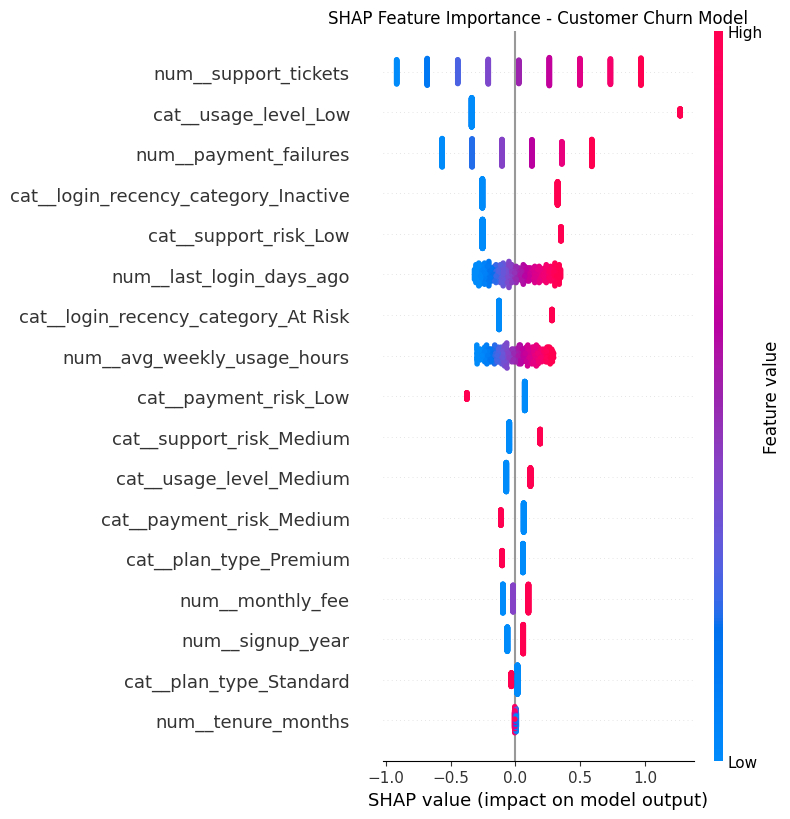

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values.values,
    X_test_transformed_df,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance - Customer Churn Model")
plt.tight_layout()
plt.show()

In [61]:
# Generate churn probabilities

test_probabilities = logistic_model.predict_proba(X_test)[:, 1]

highest_risk_position = np.argmax(test_probabilities)

highest_risk_index = X_test.index[
    highest_risk_position
]

highest_risk_probability = test_probabilities[
    highest_risk_position
]

print("Highest predicted churn probability:")
print(round(highest_risk_probability * 100, 2), "%")

print("\nCustomer index:")
print(highest_risk_index)

Highest predicted churn probability:
95.87 %

Customer index:
2460


In [62]:
customer_info = df.loc[
    highest_risk_index
]

customer_info

user_id                         2461
signup_date               2024-01-13
plan_type                      Basic
monthly_fee                      199
avg_weekly_usage_hours           3.7
support_tickets                    8
payment_failures                   5
tenure_months                      1
last_login_days_ago               45
churn                            Yes
churn_target                       1
login_recency_category      Inactive
support_risk                    High
payment_risk                    High
usage_level                      Low
Name: 2460, dtype: object

In [63]:
# SHAP explanation for highest-risk customer

customer_shap = shap_values.values[
    highest_risk_position
]

customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": customer_shap
})

customer_explanation["Absolute_SHAP"] = (
    customer_explanation["SHAP_Value"]
    .abs()
)

customer_explanation = (
    customer_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
)

customer_explanation.head(10)

,Feature,SHAP_Value,Absolute_SHAP
15,cat__usage_level_Low,1.268278,1.268278
2,num__support_tickets,0.966247,0.966247
3,num__payment_failures,0.587648,0.587648
10,cat__login_recency_category_Inactive,0.324414,0.324414
11,cat__support_risk_Low,-0.253696,0.253696
1,num__avg_weekly_usage_hours,-0.222421,0.222421
5,num__last_login_days_ago,0.182003,0.182003
9,cat__login_recency_category_At Risk,-0.126262,0.126262
0,num__monthly_fee,-0.096643,0.096643
13,cat__payment_risk_Low,0.071420,0.071420


In [64]:
# Separate churn-driving and retention-driving factors

churn_drivers = (
    customer_explanation[
        customer_explanation["SHAP_Value"] > 0
    ]
    .head(5)
)

retention_drivers = (
    customer_explanation[
        customer_explanation["SHAP_Value"] < 0
    ]
    .head(5)
)

print("Top churn-driving factors:")
print(churn_drivers[["Feature", "SHAP_Value"]])

print("\nTop retention-driving factors:")
print(retention_drivers[["Feature", "SHAP_Value"]])

Top churn-driving factors:
                                 Feature  SHAP_Value
15                  cat__usage_level_Low    1.268278
2                   num__support_tickets    0.966247
3                  num__payment_failures    0.587648
10  cat__login_recency_category_Inactive    0.324414
5               num__last_login_days_ago    0.182003

Top retention-driving factors:
                                Feature  SHAP_Value
11                cat__support_risk_Low   -0.253696
1           num__avg_weekly_usage_hours   -0.222421
9   cat__login_recency_category_At Risk   -0.126262
0                      num__monthly_fee   -0.096643
16              cat__usage_level_Medium   -0.070654


In [65]:
shap_importance.head(15)

,Feature,Mean_Absolute_SHAP
0,num__support_tickets,0.530378
1,cat__usage_level_Low,0.515052
2,num__payment_failures,0.348432
3,cat__login_recency_category_Inactive,0.285807
4,cat__support_risk_Low,0.285106
5,num__last_login_days_ago,0.169656
6,cat__login_recency_category_At Risk,0.169101
7,num__avg_weekly_usage_hours,0.149044
8,cat__payment_risk_Low,0.125623
9,cat__support_risk_Medium,0.094830


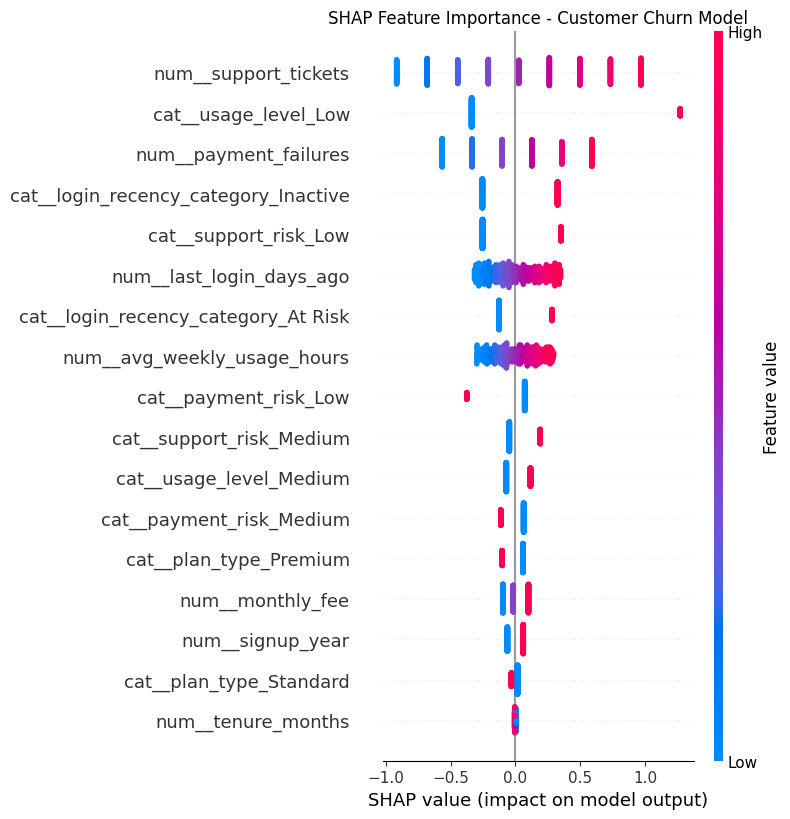

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values.values,
    X_test_transformed_df,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance - Customer Churn Model")
plt.tight_layout()

plt.savefig(
    "../dashboard_images/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
# Generate test-set churn probabilities

test_probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Find the highest-risk customer in the test set

highest_risk_position = np.argmax(test_probabilities)

highest_risk_index = X_test.index[
    highest_risk_position
]

highest_risk_probability = test_probabilities[
    highest_risk_position
]

print(
    f"Highest predicted churn probability: "
    f"{highest_risk_probability * 100:.2f}%"
)

print(
    f"Customer index: {highest_risk_index}"
)

Highest predicted churn probability: 95.87%
Customer index: 2460


In [68]:
# Display original customer information

customer_info = df.loc[highest_risk_index]

customer_info

user_id                         2461
signup_date               2024-01-13
plan_type                      Basic
monthly_fee                      199
avg_weekly_usage_hours           3.7
support_tickets                    8
payment_failures                   5
tenure_months                      1
last_login_days_ago               45
churn                            Yes
churn_target                       1
login_recency_category      Inactive
support_risk                    High
payment_risk                    High
usage_level                      Low
Name: 2460, dtype: object

In [69]:
# SHAP explanation for the highest-risk customer

customer_shap = shap_values.values[
    highest_risk_position
]

customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": customer_shap
})

customer_explanation["Absolute_SHAP"] = (
    customer_explanation["SHAP_Value"].abs()
)

customer_explanation = (
    customer_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

customer_explanation.head(10)

,Feature,SHAP_Value,Absolute_SHAP
0,cat__usage_level_Low,1.268278,1.268278
1,num__support_tickets,0.966247,0.966247
2,num__payment_failures,0.587648,0.587648
3,cat__login_recency_category_Inactive,0.324414,0.324414
4,cat__support_risk_Low,-0.253696,0.253696
5,num__avg_weekly_usage_hours,-0.222421,0.222421
6,num__last_login_days_ago,0.182003,0.182003
7,cat__login_recency_category_At Risk,-0.126262,0.126262
8,num__monthly_fee,-0.096643,0.096643
9,cat__payment_risk_Low,0.071420,0.071420


In [70]:
# Separate churn-driving and retention-driving factors

churn_drivers = (
    customer_explanation[
        customer_explanation["SHAP_Value"] > 0
    ]
    .head(5)
)

retention_drivers = (
    customer_explanation[
        customer_explanation["SHAP_Value"] < 0
    ]
    .head(5)
)

print("Top churn-driving factors:")
print(churn_drivers[["Feature", "SHAP_Value"]])

print("\nTop retention-driving factors:")
print(retention_drivers[["Feature", "SHAP_Value"]])

Top churn-driving factors:
                                Feature  SHAP_Value
0                  cat__usage_level_Low    1.268278
1                  num__support_tickets    0.966247
2                 num__payment_failures    0.587648
3  cat__login_recency_category_Inactive    0.324414
6              num__last_login_days_ago    0.182003

Top retention-driving factors:
                                Feature  SHAP_Value
4                 cat__support_risk_Low   -0.253696
5           num__avg_weekly_usage_hours   -0.222421
7   cat__login_recency_category_At Risk   -0.126262
8                      num__monthly_fee   -0.096643
10              cat__usage_level_Medium   -0.070654


## 4. Customer-Level Churn Explanation

The highest-risk customer is analyzed using SHAP values to identify the
features contributing most strongly to the predicted churn probability.

The explanation is converted into a structured format that can later
be provided to an LLM for personalized retention recommendations.

In [71]:
# Create structured customer explanation

top_churn_drivers = (
    customer_explanation[
        customer_explanation["SHAP_Value"] > 0
    ]
    .head(5)
)

customer_explanation_output = {
    "customer_id": int(customer_info["user_id"]),
    "churn_probability": round(
        float(highest_risk_probability),
        4
    ),
    "risk_category": "High Risk",
    "top_churn_drivers": [
        {
            "feature": row["Feature"],
            "shap_value": round(
                float(row["SHAP_Value"]),
                4
            )
        }
        for _, row in top_churn_drivers.iterrows()
    ]
}

customer_explanation_output

{'customer_id': 2461,
 'churn_probability': 0.9587,
 'risk_category': 'High Risk',
 'top_churn_drivers': [{'feature': 'cat__usage_level_Low',
   'shap_value': 1.2683},
  {'feature': 'num__support_tickets', 'shap_value': 0.9662},
  {'feature': 'num__payment_failures', 'shap_value': 0.5876},
  {'feature': 'cat__login_recency_category_Inactive', 'shap_value': 0.3244},
  {'feature': 'num__last_login_days_ago', 'shap_value': 0.182}]}

In [72]:
import json

explanation_path = (
    "../models/customer_2461_shap_explanation.json"
)

with open(
    explanation_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        customer_explanation_output,
        file,
        indent=4
    )

print(
    f"SHAP explanation saved successfully: "
    f"{explanation_path}"
)

SHAP explanation saved successfully: ../models/customer_2461_shap_explanation.json


In [73]:
global_shap_path = (
    "../models/global_shap_feature_importance.csv"
)

shap_importance.to_csv(
    global_shap_path,
    index=False
)

print(
    f"Global SHAP results saved successfully: "
    f"{global_shap_path}"
)

Global SHAP results saved successfully: ../models/global_shap_feature_importance.csv
